# Methane pyrolysis + HB ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for Methane pyrolysis + HB at 1,000,000 tNH3/year. The notebook shows NPV, LPM, and LCOA distributions, NPV sign counts, and mean annual cost components. Natural gas is costed as feedstock; the model adds no solid-carbon coproduct credit.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "methane_pyrolysis_hb"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tnh3,present_value_total_cost_eur,lcoa_eur_per_tnh3,levelized_profit_margin_eur_per_tnh3
0,0,methane_pyrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"1,406.507",54.945,5.309,natural_gas,...,"248,462,421.831",0.000,0.000,"653,950,247.581","236,049,752.419","1,113,271,743.019","10,674,776.189","8,387,279,064.824",785.710,104.290
1,1,methane_pyrolysis_hb,absolute,not_applicable,"1,000,000.000",25,967.662,50.126,3.904,natural_gas,...,"272,682,660.572",0.000,0.000,"714,773,659.143","175,226,340.857","902,840,257.481","10,674,776.189","8,597,710,550.363",805.423,84.577
2,2,methane_pyrolysis_hb,absolute,not_applicable,"1,000,000.000",25,882.531,43.391,4.085,natural_gas,...,"212,249,852.640",0.000,0.000,"733,560,853.161","156,439,146.839","787,421,745.370","10,674,776.189","8,713,129,062.474",816.235,73.765
3,3,methane_pyrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"1,299.858",42.933,4.524,natural_gas,...,"270,873,452.723",0.000,0.000,"713,767,911.732","176,232,088.268","581,380,394.427","10,674,776.189","8,919,170,413.417",835.537,54.463
4,4,methane_pyrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"1,209.782",50.569,4.189,natural_gas,...,"289,686,944.071",0.000,0.000,"844,033,466.038","45,966,533.962","-719,099,897.683","10,674,776.189","10,219,650,705.527",957.364,-67.364


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_profit_margin_eur_per_tnh3 = results["levelized_profit_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,"1,007.654",94.396,795.604
std,"1,600.325",149.916,149.916
min,"-5,067.863",-474.751,409.955
5%,"-1,821.172",-170.605,570.430
50%,"1,143.510",107.123,782.877
95%,"3,411.335",319.570,"1,060.605"
max,"5,124.372",480.045,"1,364.751"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),73501,0.735
1,Negative (NPV < 0),26499,0.265


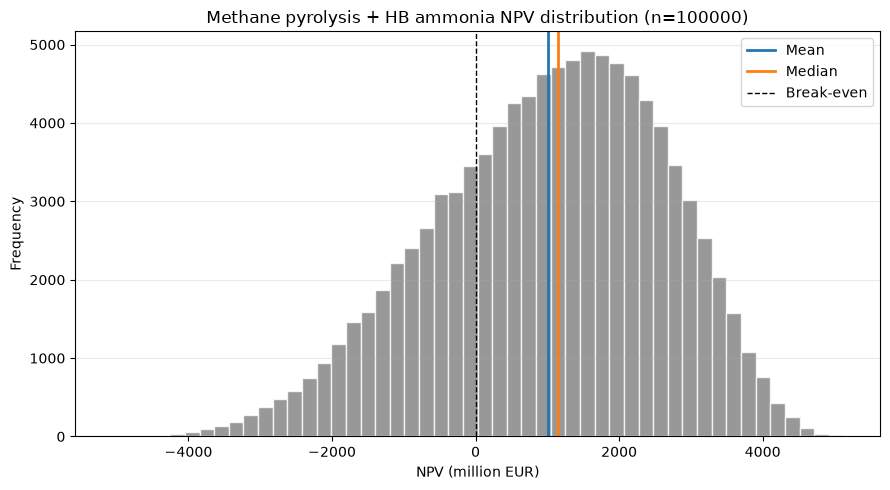

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Methane pyrolysis + HB ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

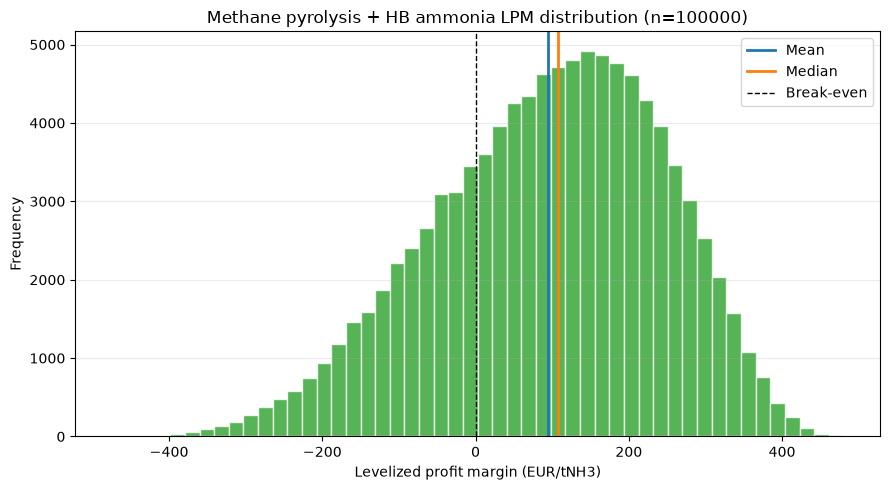

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_tnh3,
    title=f"Methane pyrolysis + HB ammonia LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

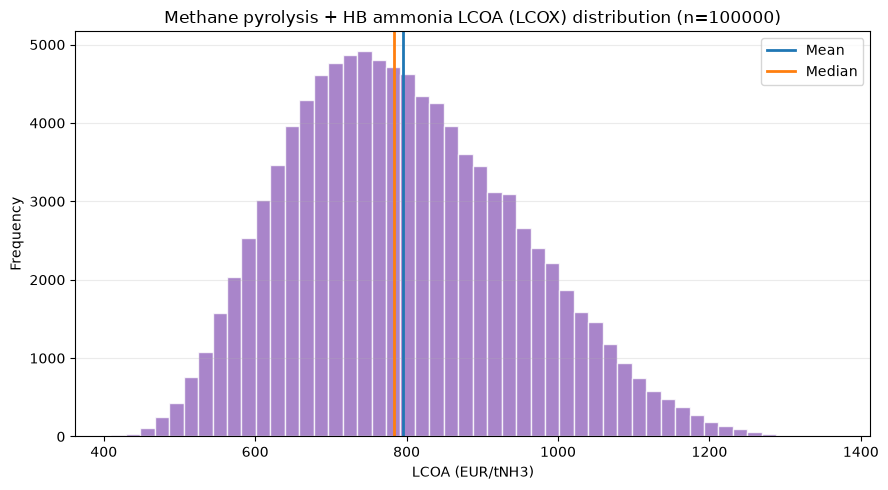

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"Methane pyrolysis + HB ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      890.000
annual_fixed_opex_eur                    49.365
annual_variable_opex_eur                  4.480
annual_natural_gas_cost_eur             384.423
annual_coal_cost_eur                      0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    384.423
annual_electricity_cost_eur             254.197
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                 0.000
annual_net_cash_flow_eur                197.536
Name: Mean annual value, million EUR, dtype: float64